<Figure size 1600x1200 with 0 Axes>

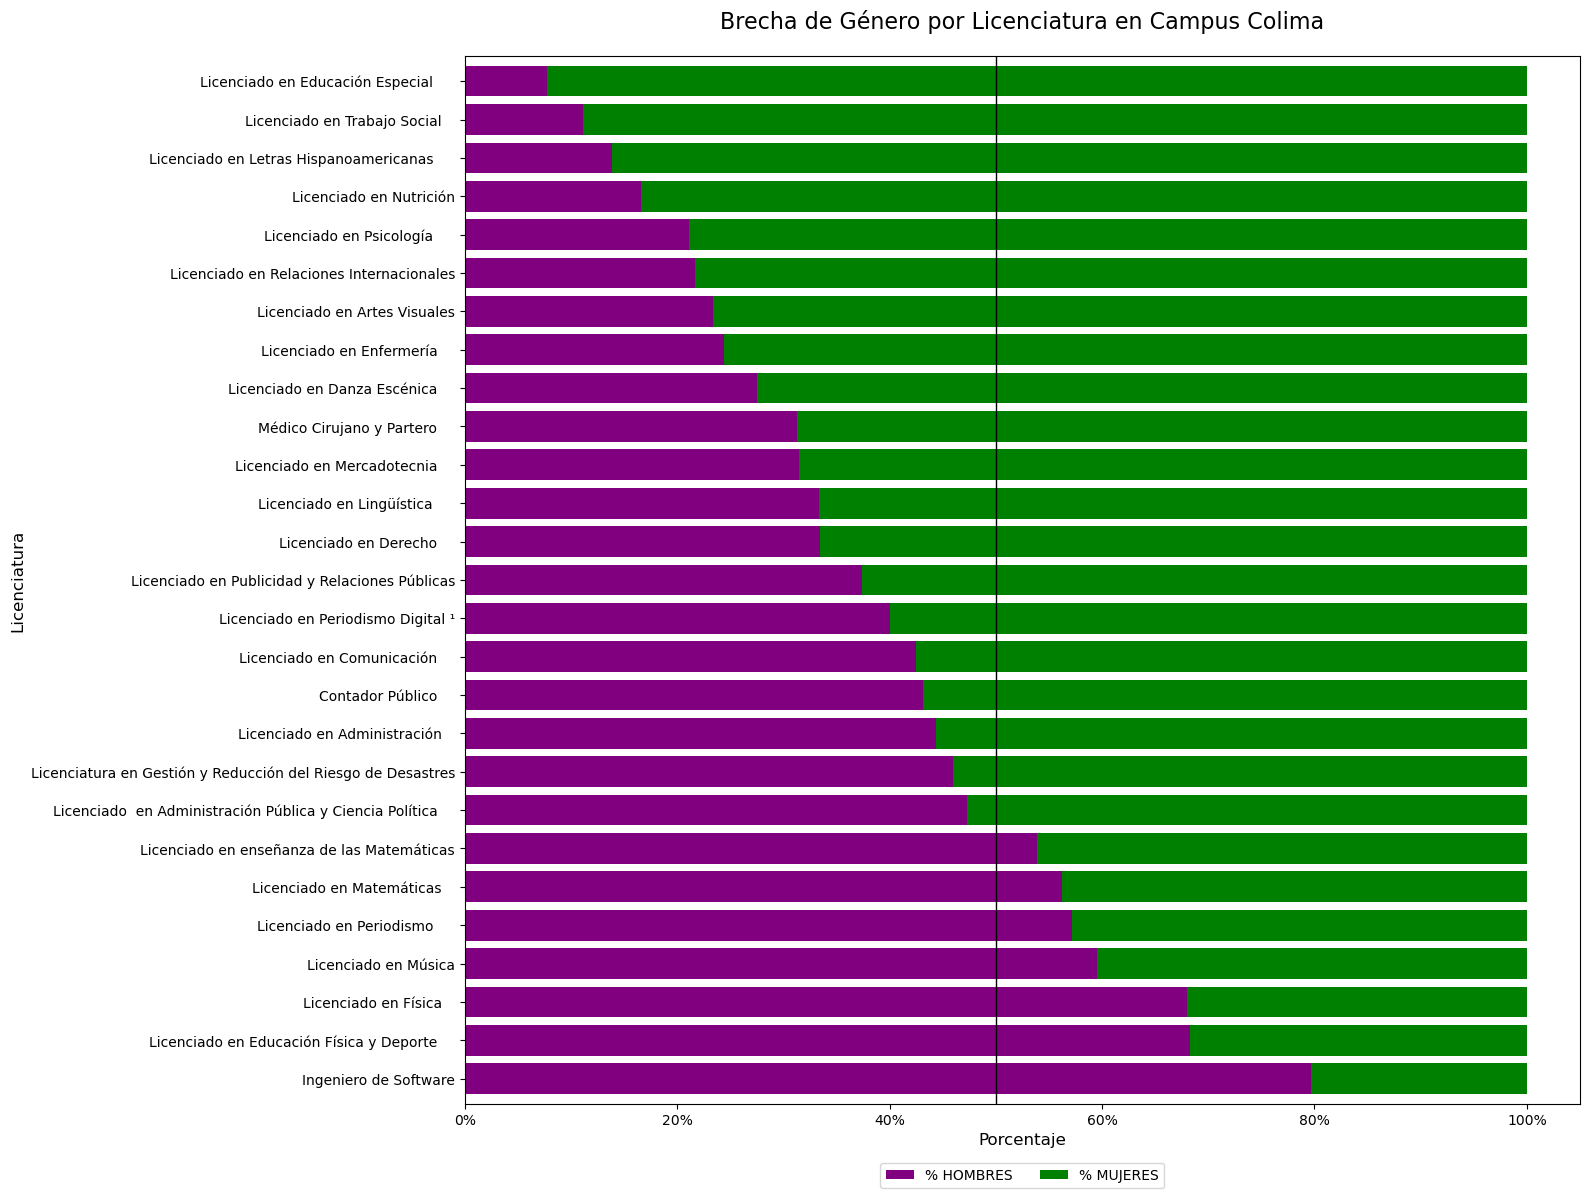

In [15]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Cargar datos
archivo = 'VFInforme_DGESUI-SES-SEP_1S-2025.xlsx'
xls = pd.ExcelFile(archivo)
df_datos = xls.parse('Primer semestre 2025 REV.OK', header=13)
df_datos.columns = df_datos.columns.str.strip()

# Renombrar columnas importantes
df_datos = df_datos.rename(columns={
    'MATRÍCULA TOTAL': 'HOMBRES',
    'Unnamed: 13': 'MUJERES',
    'Unnamed: 14': 'TOTAL',
    'NIVEL': 'NIVEL EDUCATIVO'
})

# Filtrar columnas relevantes y limpiar
df_limpio = df_datos[['NIVEL EDUCATIVO', 'MUNICIPIO', 'HOMBRES', 'MUJERES', 'TOTAL']].dropna()
df_limpio[['HOMBRES', 'MUJERES', 'TOTAL']] = df_limpio[['HOMBRES', 'MUJERES', 'TOTAL']].astype(int)

# Clasificación
def clasificar_nivel(nombre):
    nombre = nombre.lower()
    if 'bachillerato' in nombre or 'media superior' in nombre:
        return 'Media Superior'
    elif 'especialidad' in nombre or 'alta especialidad' in nombre:
        return 'Especialidad'
    elif 'maestría' in nombre:
        return 'Maestría'
    elif 'doctorado' in nombre:
        return 'Doctorado'
    elif 'licenciatura' in nombre or 'ingeniero' in nombre or 'licenciado' in nombre or 'arquitecto' in nombre or 'contador' in nombre or 'médico' in nombre:
        return 'Licenciatura'
    else:
        return 'Otro'

df_limpio['GRUPO NIVEL'] = df_limpio['NIVEL EDUCATIVO'].apply(clasificar_nivel)

# Filtrar licenciatura y calcular porcentajes por municipio y carrera
df_lic = df_limpio[df_limpio['GRUPO NIVEL'] == 'Licenciatura']
df_licencias = df_lic.groupby(['MUNICIPIO', 'NIVEL EDUCATIVO'])[['HOMBRES', 'MUJERES']].sum()
df_licencias['% MUJERES'] = 100 * df_licencias['MUJERES'] / (df_licencias['HOMBRES'] + df_licencias['MUJERES'])
df_licencias['% HOMBRES'] = 100 - df_licencias['% MUJERES']
df_licencias = df_licencias.reset_index()

# Filtrar municipio Colima
data_colima = df_licencias[df_licencias['MUNICIPIO'] == 'Colima'].sort_values('% MUJERES')

# Gráfico
plt.figure(figsize=(16, 12))
ax = data_colima.set_index('NIVEL EDUCATIVO')[['% HOMBRES', '% MUJERES']].plot(
    kind='barh',
    stacked=True,
    color=['purple', 'green'],
    figsize=(16, 12),
    width=0.8
)
plt.title('Brecha de Género por Licenciatura en Campus Colima', fontsize=16, pad=20)
plt.xlabel('Porcentaje', fontsize=12)
plt.ylabel('Licenciatura', fontsize=12)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter())

# Extender el rango del eje X y agregar línea vertical en 50%

plt.axvline(x=50, color='black', linestyle='-', linewidth=1)

# Ajustar el margen izquierdo para que las etiquetas no se encimen
plt.subplots_adjust(left=0.35, bottom=0.15)
plt.yticks(fontsize=10)
plt.tight_layout()

#save plot in jpg format
plt.savefig('brecha_genero_colima.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1600x1200 with 0 Axes>

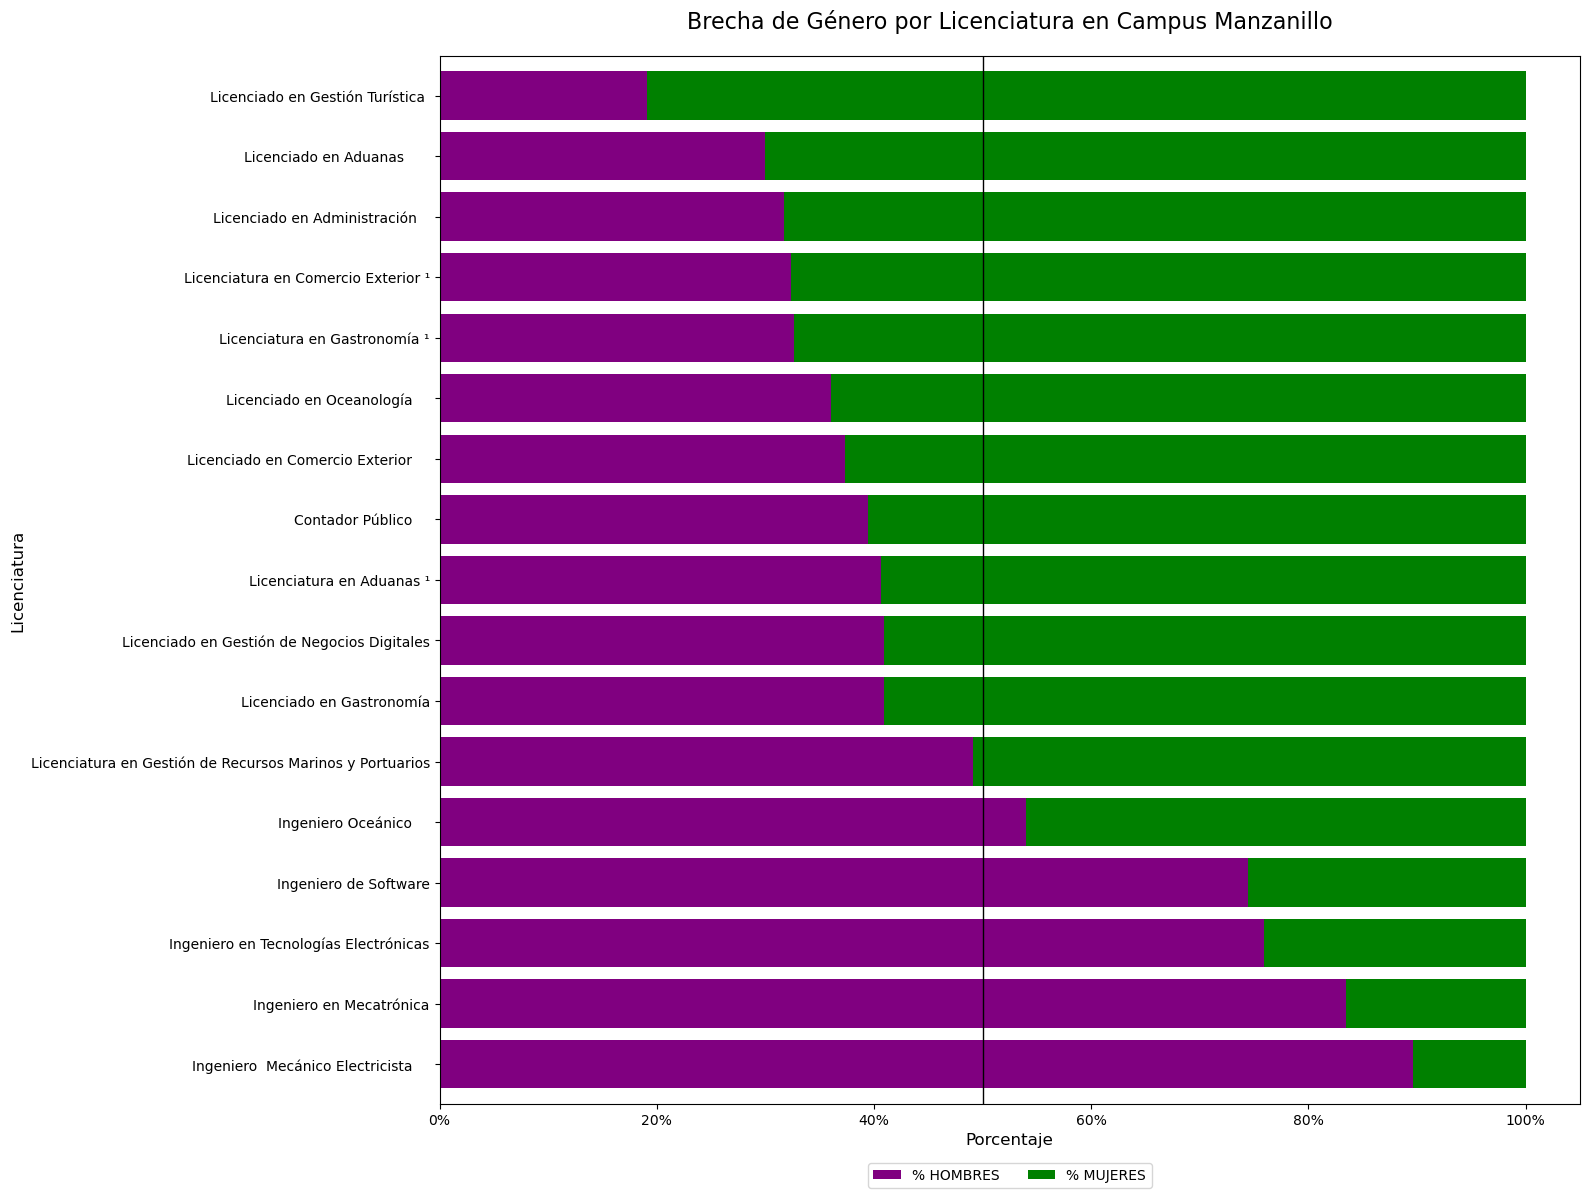

In [16]:
# Filtrar municipio Manzanillo
data_colima = df_licencias[df_licencias['MUNICIPIO'] == 'Manzanillo'].sort_values('% MUJERES')

# Gráfico
plt.figure(figsize=(16, 12))
ax = data_colima.set_index('NIVEL EDUCATIVO')[['% HOMBRES', '% MUJERES']].plot(
    kind='barh',
    stacked=True,
    color=['purple', 'green'],
    figsize=(16, 12),
    width=0.8
)
plt.title('Brecha de Género por Licenciatura en Campus Manzanillo', fontsize=16, pad=20)
plt.xlabel('Porcentaje', fontsize=12)
plt.ylabel('Licenciatura', fontsize=12)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter())

# Extender el rango del eje X y agregar línea vertical en 50%
plt.axvline(x=50, color='black', linestyle='-', linewidth=1)

# Ajustar el margen izquierdo para que las etiquetas no se encimen
plt.subplots_adjust(left=0.35, bottom=0.15)
plt.yticks(fontsize=10)
plt.tight_layout()
#save plot in jpg format
plt.savefig('brecha_genero_manzanillo.jpg', format='jpg', dpi=300, bbox_inches='tight')

<Figure size 1600x1200 with 0 Axes>

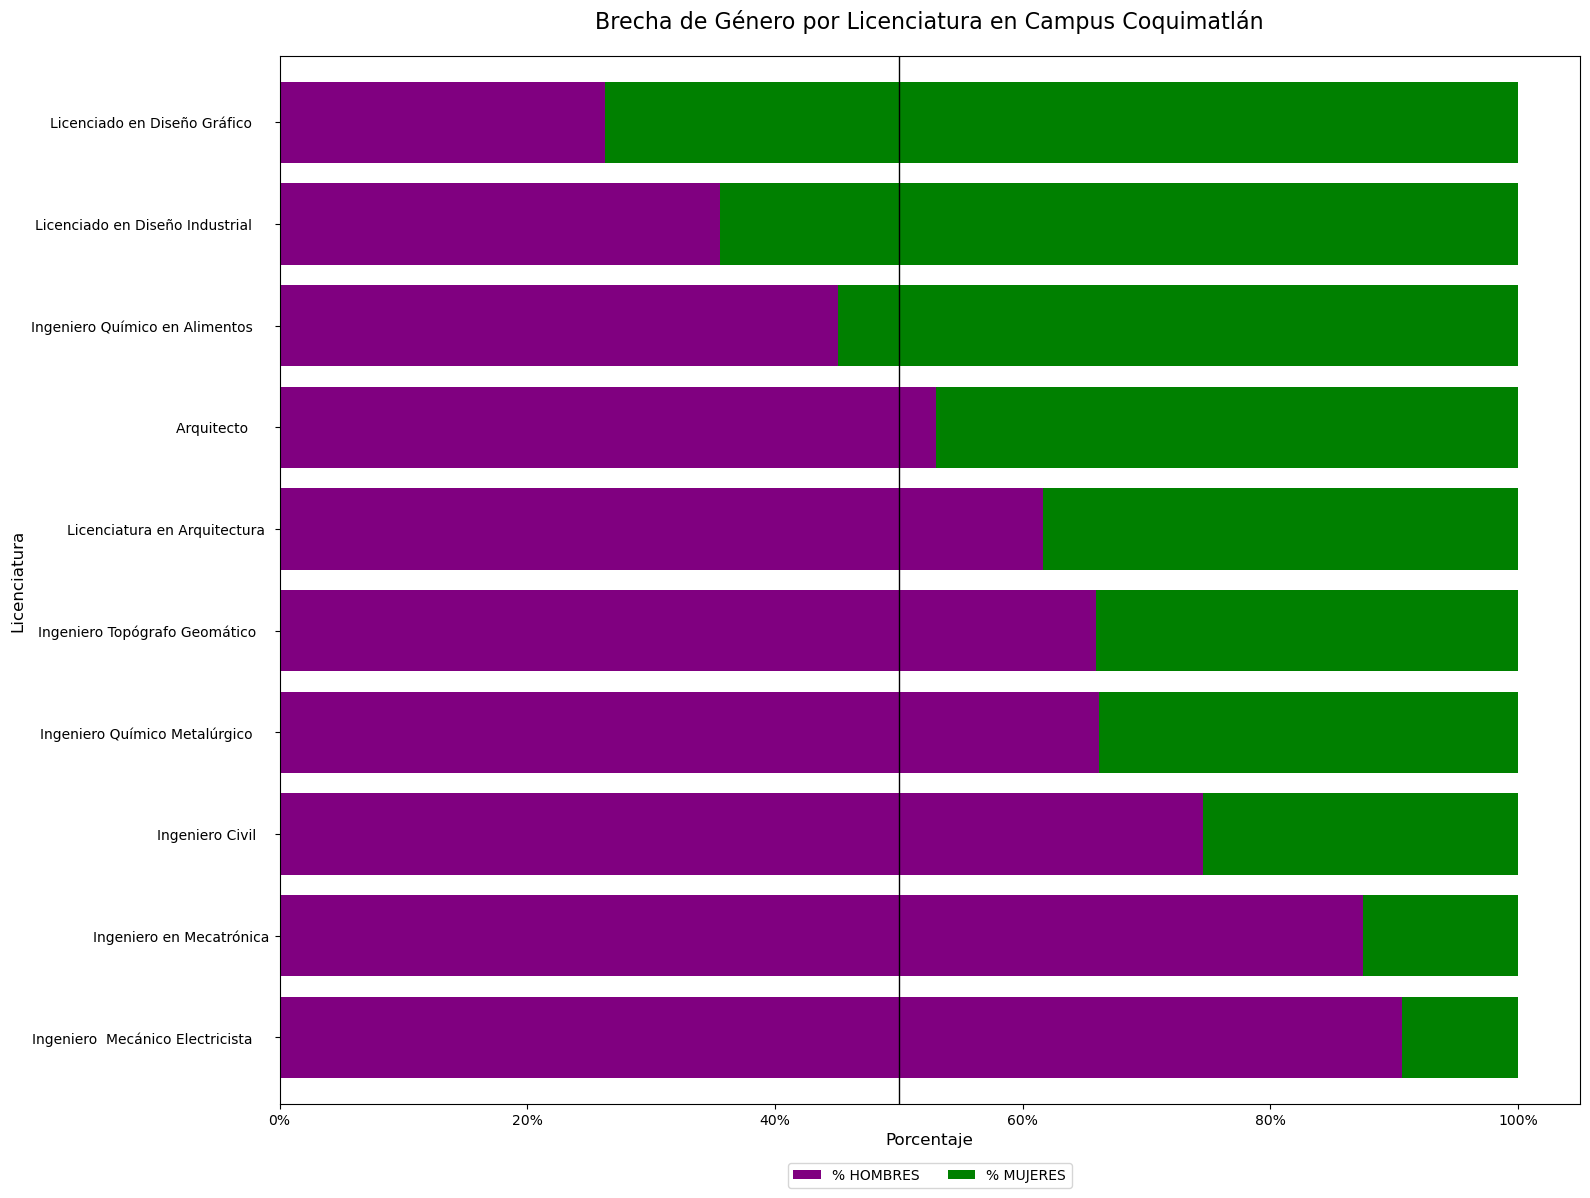

In [17]:
# Filtrar municipio Coquimatlan
data_colima = df_licencias[df_licencias['MUNICIPIO'] == 'Coquimatlán'].sort_values('% MUJERES')

# Gráfico
plt.figure(figsize=(16, 12))
ax = data_colima.set_index('NIVEL EDUCATIVO')[['% HOMBRES', '% MUJERES']].plot(
    kind='barh',
    stacked=True,
    color=['purple', 'green'],
    figsize=(16, 12),
    width=0.8
)
plt.title('Brecha de Género por Licenciatura en Campus Coquimatlán', fontsize=16, pad=20)
plt.xlabel('Porcentaje', fontsize=12)
plt.ylabel('Licenciatura', fontsize=12)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter())

# Extender el rango del eje X y agregar línea vertical en 50%
plt.axvline(x=50, color='black', linestyle='-', linewidth=1)

# Ajustar el margen izquierdo para que las etiquetas no se encimen
plt.subplots_adjust(left=0.35, bottom=0.15)
plt.yticks(fontsize=10)
plt.tight_layout()
#save plot in jpg format
plt.savefig('brecha_genero_coquimatlan.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1600x1200 with 0 Axes>

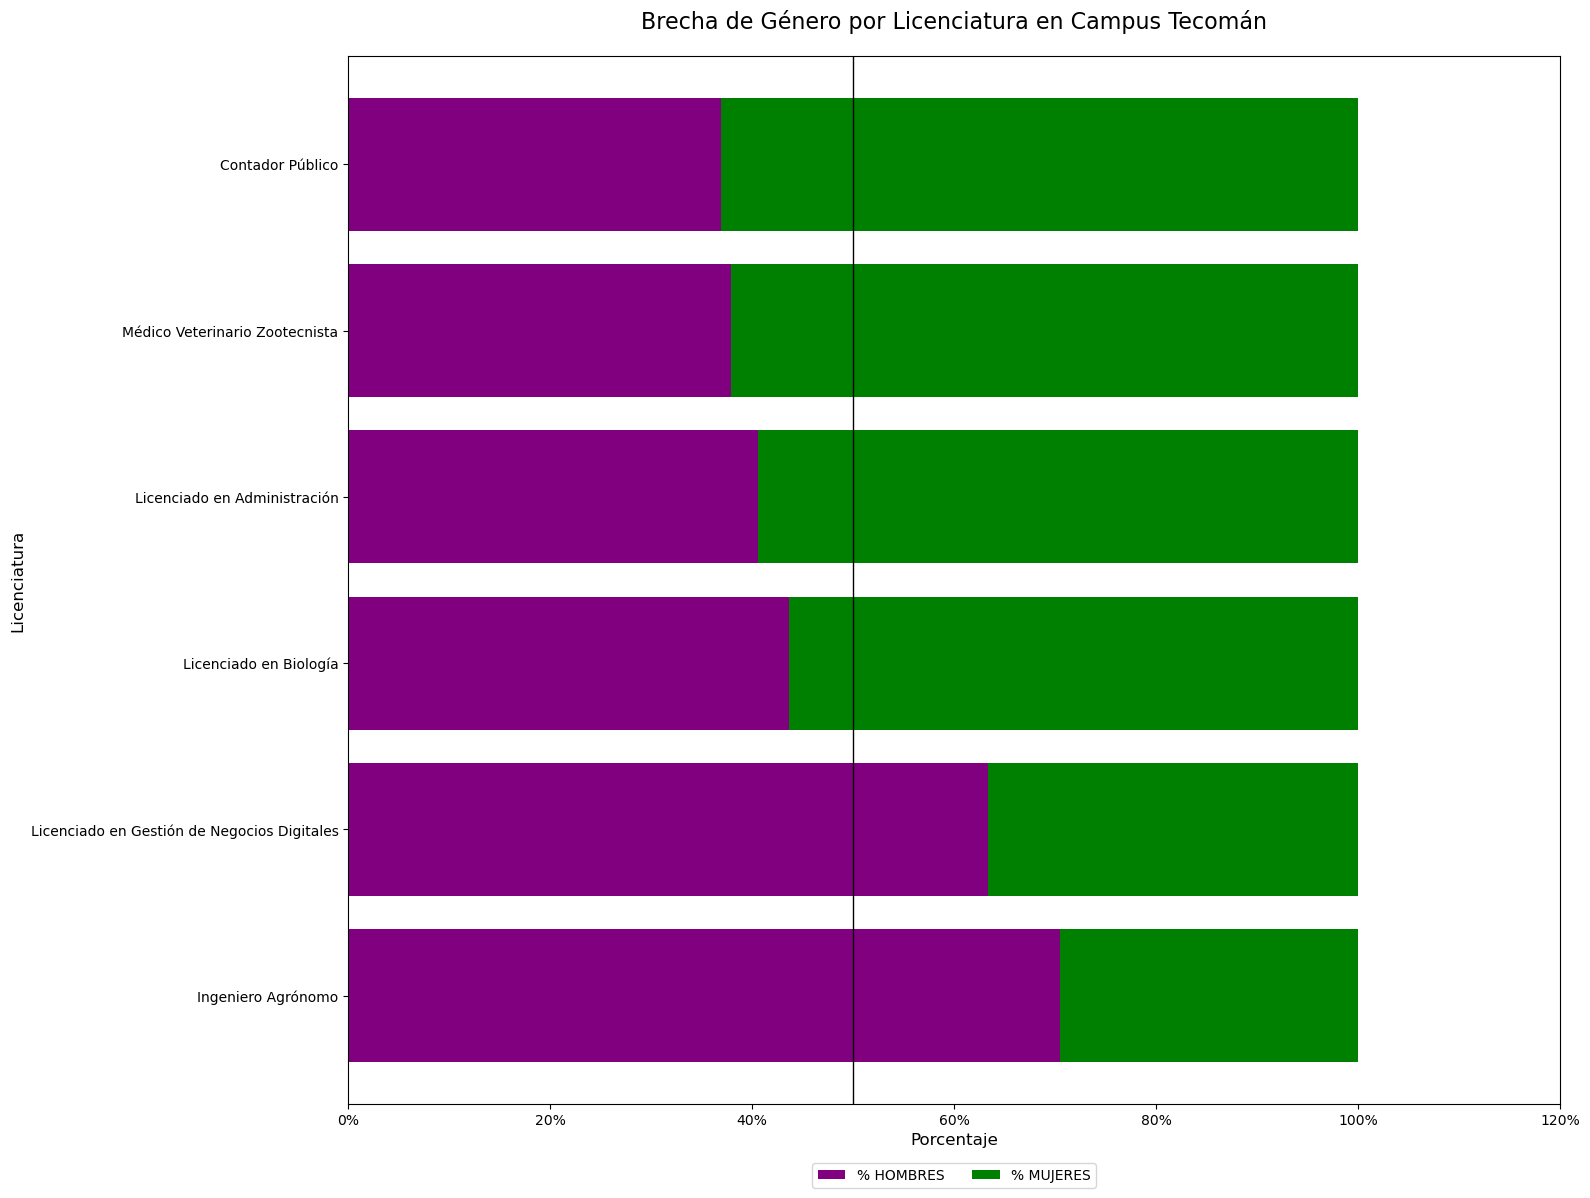

In [18]:
# Filtrar municipio Tecoman
data_colima = df_licencias[df_licencias['MUNICIPIO'] == 'Tecomán'].sort_values('% MUJERES')

# Gráfico
plt.figure(figsize=(16, 12))
ax = data_colima.set_index('NIVEL EDUCATIVO')[['% HOMBRES', '% MUJERES']].plot(
    kind='barh',
    stacked=True,
    color=['purple', 'green'],
    figsize=(16, 12),
    width=0.8
)
plt.title('Brecha de Género por Licenciatura en Campus Tecomán', fontsize=16, pad=20)
plt.xlabel('Porcentaje', fontsize=12)
plt.ylabel('Licenciatura', fontsize=12)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter())

# Extender el rango del eje X y agregar línea vertical en 50%
plt.xlim(0, 120)
plt.axvline(x=50, color='black', linestyle='-', linewidth=1)

# Ajustar el margen izquierdo para que las etiquetas no se encimen
plt.subplots_adjust(left=0.35, bottom=0.15)
plt.yticks(fontsize=10)
plt.tight_layout()
#save plot in jpg format
plt.savefig('brecha_genero_tecoman.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1600x1200 with 0 Axes>

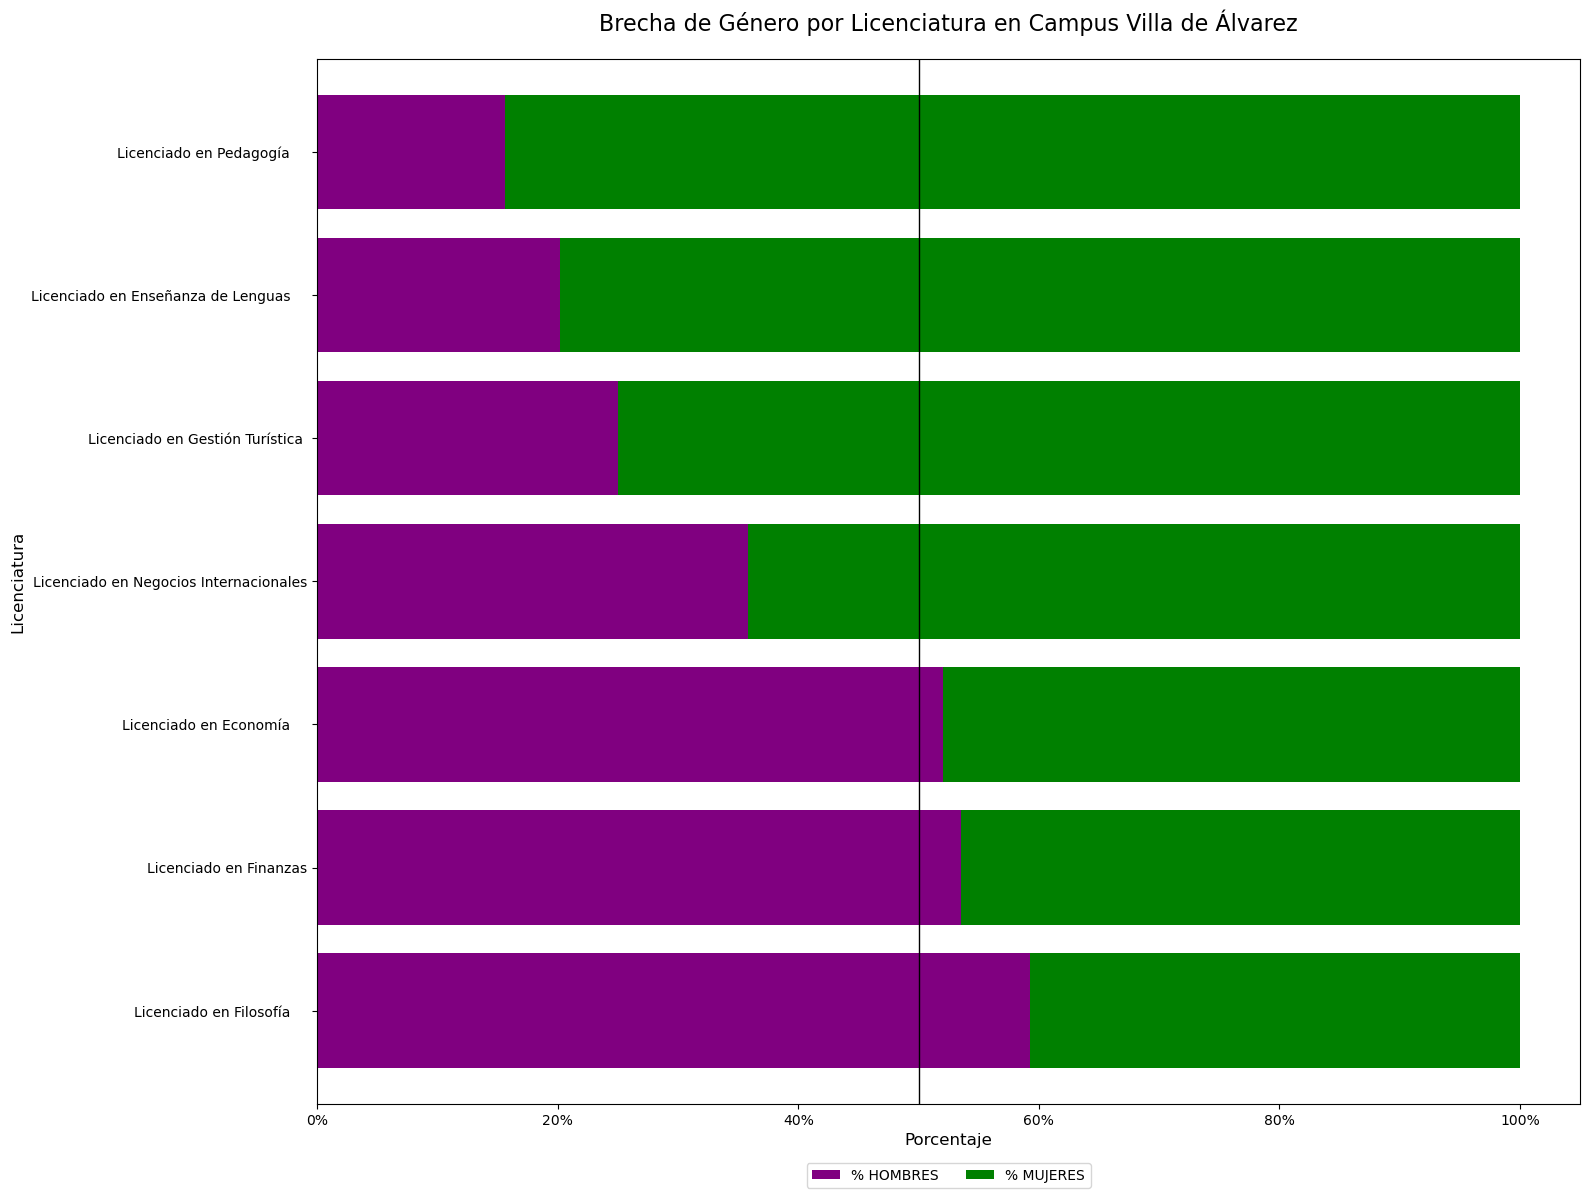

In [19]:
# Filtrar municipio Villa de Álvarez
data_colima = df_licencias[df_licencias['MUNICIPIO'] == 'Villa de Álvarez'].sort_values('% MUJERES')

# Gráfico
plt.figure(figsize=(16, 12))
ax = data_colima.set_index('NIVEL EDUCATIVO')[['% HOMBRES', '% MUJERES']].plot(
    kind='barh',
    stacked=True,
    color=['purple', 'green'],
    figsize=(16, 12),
    width=0.8
)
plt.title('Brecha de Género por Licenciatura en Campus Villa de Álvarez', fontsize=16, pad=20)
plt.xlabel('Porcentaje', fontsize=12)
plt.ylabel('Licenciatura', fontsize=12)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter())

# Extender el rango del eje X y agregar línea vertical en 50%
plt.axvline(x=50, color='black', linestyle='-', linewidth=1)

# Ajustar el margen izquierdo para que las etiquetas no se encimen
plt.subplots_adjust(left=0.35, bottom=0.15)
plt.yticks(fontsize=10)
plt.tight_layout()
#save plot in jpg format
plt.savefig('brecha_genero_villa_alvarez.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

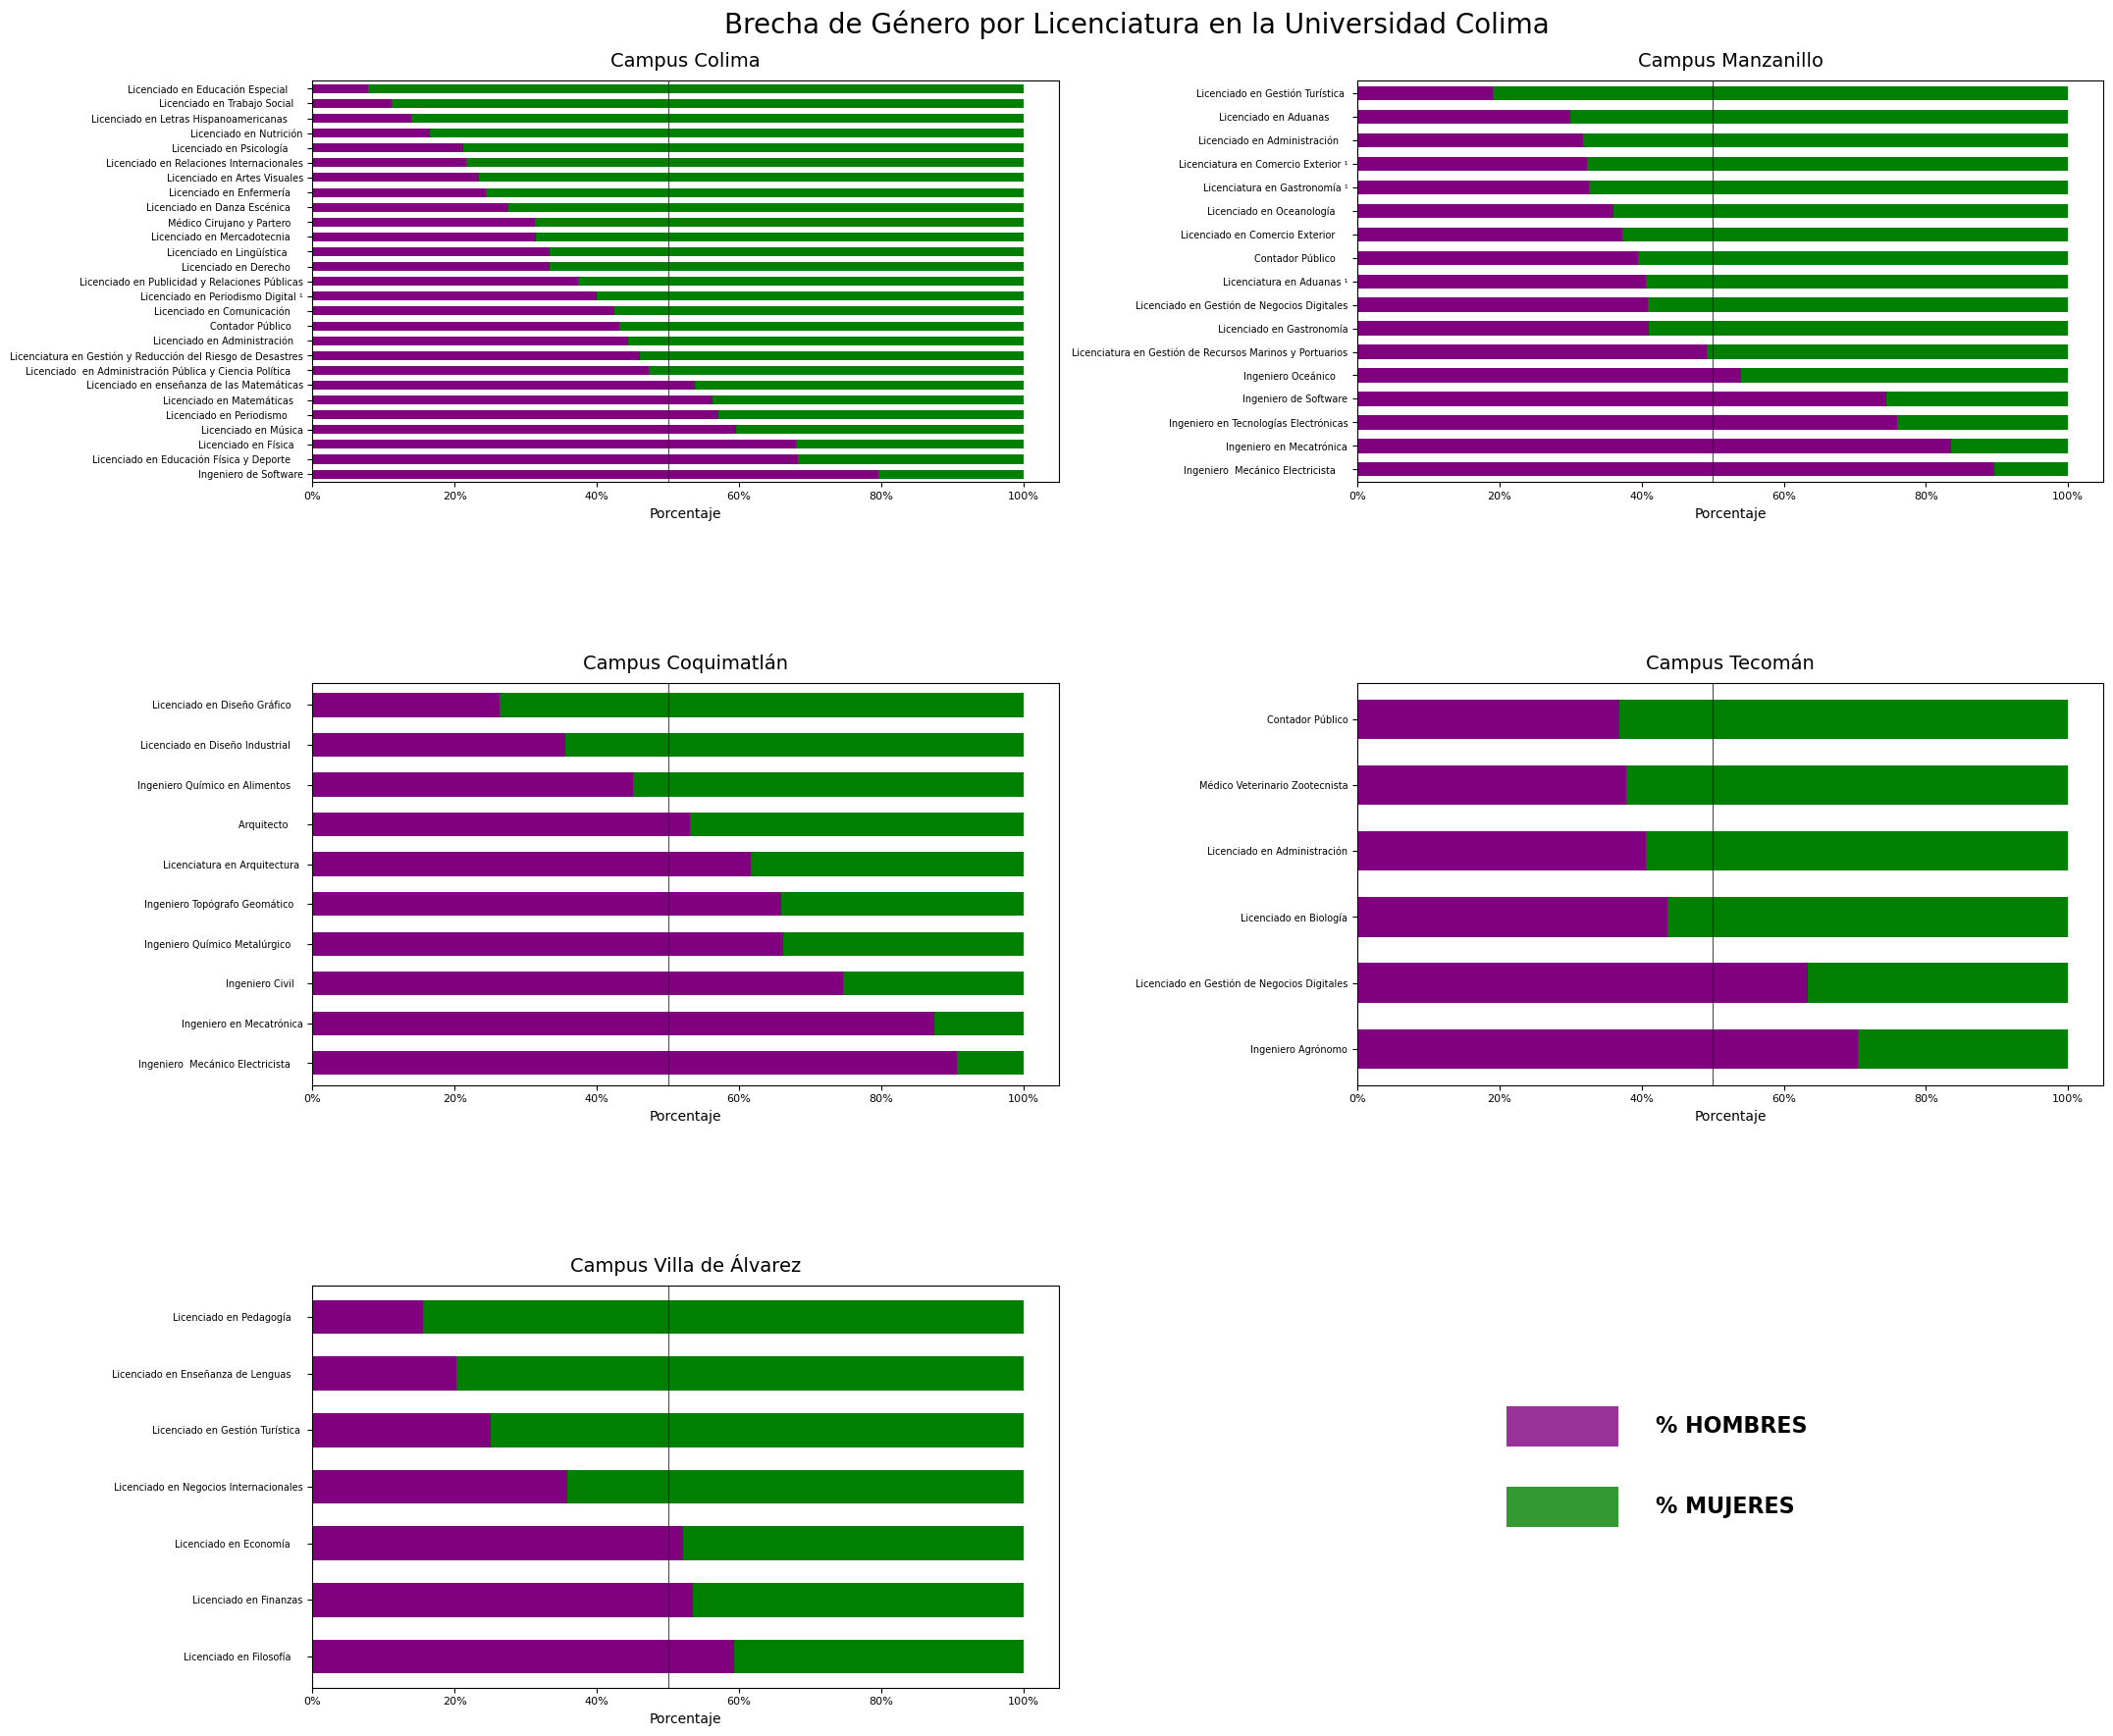

In [20]:
# graficar todas las graficas en un solo panel dividido por municipio
fig, axs = plt.subplots(3, 2, figsize=(20, 18))
fig.suptitle('Brecha de Género por Licenciatura en la Universidad Colima', fontsize=20, y=0.98)

# Lista de municipios
municipios = ['Colima', 'Manzanillo', 'Coquimatlán', 'Tecomán', 'Villa de Álvarez']
posiciones = [(0, 0), (0, 1), (1, 0), (1, 1), (2, 0)]

for i, municipio in enumerate(municipios):
    # Filtrar datos por municipio
    data_municipio = df_licencias[df_licencias['MUNICIPIO'] == municipio].sort_values('% MUJERES')
    
    if len(data_municipio) > 0:  # Solo graficar si hay datos
        row, col = posiciones[i]
        
        # Crear gráfico
        data_municipio.set_index('NIVEL EDUCATIVO')[['% HOMBRES', '% MUJERES']].plot(
            kind='barh',
            stacked=True,
            color=['purple', 'green'],
            ax=axs[row, col],
            width=0.6
        )
        
        # Configurar cada subgráfico
        axs[row, col].set_title(f'Campus {municipio}', fontsize=14, pad=10)
        axs[row, col].set_xlabel('Porcentaje', fontsize=10)
        axs[row, col].set_ylabel('')  # Quitar etiqueta del eje Y para evitar solapamiento
        axs[row, col].tick_params(axis='y', labelsize=7)
        axs[row, col].tick_params(axis='x', labelsize=8)
        axs[row, col].xaxis.set_major_formatter(mtick.PercentFormatter())
        
        # Agregar línea vertical en 50%
        axs[row, col].axvline(x=50, color='black', linestyle='-', linewidth=0.8, alpha=0.7)
        
        # Configurar límites del eje X
        axs[row, col].set_xlim(0, 105)
        
        # Quitar leyenda individual de cada gráfico
        axs[row, col].legend().set_visible(False)

# Usar el panel vacío para la leyenda
axs[2, 1].axis('off')  # Quitar ejes
# Crear una leyenda grande en el panel vacío
from matplotlib.patches import Rectangle
axs[2, 1].add_patch(Rectangle((0.2, 0.6), 0.15, 0.1, facecolor='purple', alpha=0.8))
axs[2, 1].add_patch(Rectangle((0.2, 0.4), 0.15, 0.1, facecolor='green', alpha=0.8))
axs[2, 1].text(0.4, 0.65, '% HOMBRES', fontsize=16, fontweight='bold', va='center')
axs[2, 1].text(0.4, 0.45, '% MUJERES', fontsize=16, fontweight='bold', va='center')
axs[2, 1].set_xlim(0, 1)
axs[2, 1].set_ylim(0, 1)

# Ajustar espaciado
plt.tight_layout()
plt.subplots_adjust(top=0.94, hspace=0.5, wspace=0.4, left=0.08)

# Guardar la figura
plt.savefig('brecha_genero_todos_municipios.jpg', format='jpg', dpi=300, bbox_inches='tight')
#pdf
plt.savefig('brecha_genero_todos_municipios.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()



